Scenario: Predicting Athlete Sprint Times
A sports academy wants to build a model to predict athlete sprint times based on training hours.
They collect data from 30 athletes, but sprint times are noisy due to diet, fatigue, or weather.
They try two different models:
- Linear Model (straight line) → assumes sprint times improve perfectly with more training.
- Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

Questions
- Part A: If the linear model consistently predicts too fast or too slow sprint times,
  what does this show about bias?
- Part B: If the polynomial model fits training data almost perfectly but gives very different
  predictions for new athletes, what does this show about variance?
- Part C: Which model is likely to generalize better to new athletes, and why?
- Part D (Applied): How would you explain “high bias” vs “high variance” to a coach?

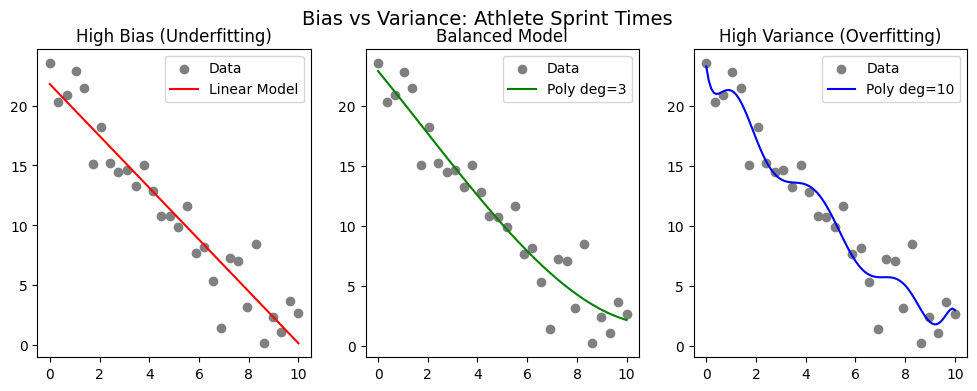

In [1]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
np.random.seed(0)
X = np.linspace(0, 10, 30).reshape(-1, 1)   # training hours
y = (20 - 2 * X + 0.5 * np.sin(X)).ravel() + np.random.normal(scale=2, size=30)  # sprint times with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression())

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Athlete Sprint Times", fontsize=14)
plt.show()